# Notebook 2 — Map-matching et découpage en sous-tronçons

## Objectif

Transformer nos 149 traces GPX stockées sous forme de points bruts en
**séquences d'arêtes OSM identifiables**, puis construire une **heatmap club
par arête** et **découper les boucles en sous-tronçons** réutilisables pour
le routing A→B du Notebook 4+.

Sans map-matching, on n'a que des nuages de points. Deux traces qui parcourent
la même route ne pointent vers rien de commun côté data. Une fois
map-matchées, elles partagent les mêmes `edge_id` OSM, ce qui permet :
- d'agréger ("combien de fois le club est passé sur cette arête ?")
- de découper ("voici 12 tronçons de 5-15 km validés par le club")
- de router ("A→B en privilégiant les arêtes club-worthy")

## Principe du map-matching

Les traces GPX sont bruitées : le GPS dévie de 5-50 m selon la zone (forêt,
urbain dense, tunnel). Visuellement tu vois la ligne onduler autour de la
route réelle, couper à travers un pâté de maisons, sauter d'un côté à l'autre.

Le map-matcher résout ça avec un **Hidden Markov Model + Viterbi** :
- À chaque point GPS, on liste les arêtes OSM candidates dans un rayon
- On construit un graphe des chemins possibles (candidat_1 → candidat_2 → …)
- On pondère par (proximité de l'arête au point GPS) et (plausibilité de
  transition entre arêtes consécutives via un routing)
- Viterbi trouve la séquence la plus probable

Le résultat : une liste ordonnée d'arêtes OSM (`way_id`, `edge_id`) avec leurs
attributs (longueur, type de route, surface…).

## Pourquoi Valhalla / Meili

- Gratuit, open source, docker-ready
- Qualité de matching excellente pour du vélo (profil `bicycle` dédié avec
  option `road`/`gravel`/`cross`/`mountain`)
- Renvoie directement `way_id` OSM (ID stable, pérenne entre updates)
- API REST simple (`trace_attributes`)

Alternative sérieuse : **GraphHopper** (profil `racingbike` natif). Choix
quasi équivalent, Valhalla est juste un peu plus simple à piloter en Python.

## Papiers à revoir

- **Newson, Krumm (2009)**. *Hidden Markov map matching through noise and
  sparseness*. ACM SIGSPATIAL. L'article fondateur de la méthode HMM qu'on
  utilise sous le capot.
- **Lu, Shahabi (2015)** pour rappel : l'algo AOP du Notebook 6 s'appliquera
  sur les `edge_id` qu'on produit ici.

## Plan de ce notebook

1. Setup Valhalla en Docker local
2. Connexion DB + récupération des traces
3. Paramètres de matching (search_radius, gps_accuracy, sampling)
4. Fonction de map-matching unitaire + test sur 1 trace
5. Batch sur toutes les traces avec gestion d'erreurs
6. Insertion en DB (`osm_edges` + `trace_edges`)
7. Calcul de la heatmap club (vue SQL)
8. Découpage des boucles en sous-tronçons
9. QC visuel : comparaison trace brute vs trace matchée sur carte
10. Rapport final

## Prérequis côté Windows

### Docker Desktop installé

Télécharger depuis https://www.docker.com/products/docker-desktop/. Install en
admin, reboot, puis vérifier en ouvrant un terminal :

```bash
docker --version
```

Doit renvoyer `Docker version 2x.x.x, ...` sans erreur. Si problème WSL2,
suivre l'assistant Microsoft (c'est fait automatiquement sur Win10/11 récents).

### Extrait OSM Île-de-France

Télécharger https://download.geofabrik.de/europe/france/ile-de-france-latest.osm.pbf
(~300 MB) et placer le fichier dans un dossier dédié qu'on passera à Valhalla.

### Espace disque

Prévoir ~5 GB : les tuiles Valhalla construites à partir de l'IdF
occupent 2-3 GB, plus le cache Docker.


## 1. Setup Valhalla en Docker

On lance Valhalla avec l'image officielle `gis-ops/docker-valhalla` qui est la
plus user-friendly. Au premier démarrage, Valhalla va construire les tuiles de
routing à partir du fichier `.osm.pbf` — ça prend 10-20 min une fois pour
toutes. Ensuite le serveur démarre sur le port 8002.

### Commande Docker à lancer dans un terminal séparé

**Windows PowerShell :**
```powershell
# Créer un dossier pour les fichiers Valhalla
mkdir C:\valhalla_data
cd C:\valhalla_data

# Télécharger l'extrait IdF (une seule fois)
# Si tu as curl installé (par défaut sur Win11) :
curl -o ile-de-france-latest.osm.pbf https://download.geofabrik.de/europe/france/ile-de-france-latest.osm.pbf

# OU téléchargement manuel depuis le navigateur sur geofabrik.de et placer
# le fichier dans C:\valhalla_data\

# Lancer Valhalla
docker run -dt --name valhalla_idf `
  -p 8002:8002 `
  -v C:\valhalla_data:/custom_files `
  ghcr.io/gis-ops/docker-valhalla/valhalla:latest
```

### Suivre la progression

```powershell
docker logs -f valhalla_idf
```

Tu verras les étapes :
1. Parsing du PBF
2. Construction des tuiles (le long)
3. Construction des hiérarchies
4. Démarrage du serveur → message `Running server on ...:8002`

### Vérifier que Valhalla répond

Une fois le serveur prêt, teste depuis le notebook ou un navigateur :
http://localhost:8002/status

Retour attendu : un JSON avec `version`, `tileset_last_modified`, etc.

### Gestion du conteneur

```powershell
# Arrêter
docker stop valhalla_idf

# Redémarrer (rapide, les tuiles sont déjà construites)
docker start valhalla_idf

# Supprimer complètement si tu veux repartir à zéro
docker rm -f valhalla_idf
```


In [22]:
# Test de connexion à Valhalla
# Exécute cette cellule pour vérifier que le serveur répond

import requests

VALHALLA_URL = "http://localhost:8002"

try:
    r = requests.get(f"{VALHALLA_URL}/status", timeout=5)
    r.raise_for_status()
    info = r.json()
    print("✓ Valhalla répond")
    print(f"  Version          : {info.get('version')}")
    print(f"  Tileset modifié  : {info.get('tileset_last_modified')}")
    print(f"  Bbox supportée   : {info.get('bbox')}")
except requests.exceptions.ConnectionError:
    print("✗ Valhalla ne répond pas sur", VALHALLA_URL)
    print("  → vérifie que le conteneur Docker est lancé :")
    print("    docker ps | findstr valhalla")
except Exception as e:
    print(f"✗ Erreur : {e}")

✓ Valhalla répond
  Version          : 3.5.1
  Tileset modifié  : 1776628573
  Bbox supportée   : None


## 2. Imports et connexion DB

On récupère les traces de la DB PostGIS peuplée au Notebook 1.

In [23]:
# Standard
from pathlib import Path
import json
import time
import warnings
warnings.filterwarnings("ignore")

# Data
import numpy as np
import pandas as pd
from tqdm.auto import tqdm

# DB
from sqlalchemy import create_engine, text

# HTTP (appels Valhalla)
import requests

# Géométrie
from shapely.geometry import LineString, Point
from shapely import wkt

# Visualisation
import folium
import matplotlib.pyplot as plt

# Parallélisation (optionnelle)
from concurrent.futures import ThreadPoolExecutor, as_completed

pd.set_option('display.max_columns', 50)
print("Imports OK")

Imports OK


In [24]:
# --- Connexion DB : À ADAPTER ---
DB_CONFIG = {
    "user":     "postgres",
    "password": "4421",           # ← ton mot de passe
    "host":     "localhost",
    "port":     5432,
    "database": "velo_club",
}

url = (f"postgresql+psycopg2://{DB_CONFIG['user']}:{DB_CONFIG['password']}"
       f"@{DB_CONFIG['host']}:{DB_CONFIG['port']}/{DB_CONFIG['database']}")
engine = create_engine(url, pool_pre_ping=True)

# Test
with engine.connect() as conn:
    n = conn.execute(text("SELECT COUNT(*) FROM traces WHERE is_idf AND is_loop")).scalar()
print(f"Traces exploitables en base : {n}")

Traces exploitables en base : 128


## 3. Paramètres de matching

### Les paramètres critiques

| Param | Valeur défaut | Rôle |
|---|---|---|
| `search_radius` | **50 m** | rayon de recherche d'arêtes candidates autour de chaque point GPS |
| `gps_accuracy` | **5 m** | écart-type GPS supposé (pondération HMM) |
| `shape_match` | **`map_snap`** | méthode : HMM complet (vs walk=exact match) |
| `costing` | **`bicycle`** | profil de routing utilisé pour les transitions |
| `bicycle_type` | **`road`** | sous-type vélo de route |

### Sampling des points

Les traces ont en moyenne 2000 points pour 100 km (~1 point toutes les 50 m).
On sous-échantillonne à **1 point tous les 8 points** = ~1 point tous les
400 m, ce qui :
- divise le temps de calcul par 8
- reste largement suffisant pour un matching fiable
- évite les problèmes liés aux trop petits déplacements entre points

### Découpage des longues traces

Valhalla a une limite par défaut de ~200 km par appel. Pour des traces > 150 km
(tu en as quelques-unes), on découpe en segments de 100 km avec recouvrement
de 500 m pour raccorder proprement.

In [25]:
# --- Paramètres de matching ---
MATCH_PARAMS = {
    "search_radius":     50,       # rayon candidats, en mètres
    "gps_accuracy":      5.0,      # écart-type GPS supposé
    "interpolation_distance": 10,  # distance min entre points (mètres)
}

BICYCLE_COSTING_OPTIONS = {
    "bicycle_type":            "Road",    # Road / Cross / Hybrid / Mountain
    "cycling_speed":           25,        # km/h attendus
    "use_roads":               0.5,       # 0=évite routes, 1=aime routes
    "use_hills":               0.5,       # 0=évite côtes, 1=aime côtes
    "avoid_bad_surfaces":      0.25,
}

# Sampling : on garde 1 point sur N pour alléger
SAMPLING_STRIDE = 8

# Découpage des longues traces
MAX_SEGMENT_KM = 100
OVERLAP_M      = 500

# Attributs qu'on veut récupérer de Valhalla
TRACE_ATTRS = [
    "edge.way_id",            # ID OSM stable
    "edge.id",                # ID Valhalla interne
    "edge.length",            # longueur en km
    "edge.names",             # noms de rues
    "edge.road_class",        # primary/secondary/tertiary/residential
    "edge.use",                # road/cycleway/footway/…
    "edge.surface",
    "edge.speed",
    "edge.weighted_grade",    # pente pondérée (hill avoidance)
    "edge.begin_shape_index",
    "edge.end_shape_index",
    "edge.cycle_lane",        # présence voie cyclable
    "edge.bicycle_network",   # lcn/rcn/ncn
    "edge.traversability",    # forward/backward/both
    "matched.point",          # coord matchée
    "matched.type",           # matched / interpolated / unmatched
    "matched.edge_index",
    "matched.distance_along_edge",
    "matched.distance_from_trace_point",
    "shape",                  # géométrie matchée complète
]

print("Paramètres de matching configurés")

Paramètres de matching configurés


## 4. Fonction de map-matching unitaire

On encapsule tout dans une fonction qui prend une trace (liste de points) et
renvoie un dict structuré avec les arêtes matchées. On gère :
- Sous-échantillonnage
- Découpage si trop long
- Appel HTTP avec timeout et retry
- Gestion des erreurs (trace hors zone, matching impossible, etc.)

In [26]:
def haversine_m(lat1, lon1, lat2, lon2):
    """Distance haversine en mètres. Réutilisé depuis Notebook 1."""
    from math import radians, sin, cos, atan2, sqrt
    R = 6371000.0
    phi1, phi2 = radians(lat1), radians(lat2)
    dphi = radians(lat2 - lat1)
    dlambda = radians(lon2 - lon1)
    a = sin(dphi/2)**2 + cos(phi1)*cos(phi2)*sin(dlambda/2)**2
    return 2 * R * atan2(sqrt(a), sqrt(1 - a))


def subsample_points(pts, stride=SAMPLING_STRIDE):
    """Garde 1 point tous les `stride`, + toujours le premier et le dernier."""
    if len(pts) <= stride:
        return pts
    sampled = pts[::stride]
    # S'assurer que le dernier point est inclus
    if sampled[-1] is not pts[-1]:
        sampled.append(pts[-1])
    return sampled


def split_long_trace(pts, max_km=MAX_SEGMENT_KM, overlap_m=OVERLAP_M):
    """
    Découpe une trace longue en segments de max_km avec recouvrement.
    Retourne une liste de listes de points.
    """
    if not pts:
        return []

    # Calcul cumul des distances
    cumd = [0.0]
    for i in range(1, len(pts)):
        d = haversine_m(pts[i-1]["lat"], pts[i-1]["lon"],
                        pts[i]["lat"], pts[i]["lon"])
        cumd.append(cumd[-1] + d)

    total_m = cumd[-1]
    if total_m <= max_km * 1000:
        return [pts]

    segments = []
    seg_start = 0
    target = max_km * 1000
    i = 1
    while i < len(pts):
        if cumd[i] - cumd[seg_start] >= target:
            segments.append(pts[seg_start:i+1])
            # Recul de `overlap_m` pour le prochain segment
            back = i
            while back > 0 and cumd[i] - cumd[back] < overlap_m:
                back -= 1
            seg_start = back
            i = seg_start + 1
        else:
            i += 1
    # Dernier segment
    if seg_start < len(pts) - 1:
        segments.append(pts[seg_start:])
    return segments


def call_valhalla_trace_attributes(points, timeout=60):
    """
    Appel à Valhalla trace_attributes.
    Retourne (edges, matched_points) ou lève une exception.
    """
    shape = [{"lat": p["lat"], "lon": p["lon"]} for p in points]
    payload = {
        "shape":       shape,
        "costing":     "bicycle",
        "shape_match": "map_snap",
        "costing_options": {"bicycle": BICYCLE_COSTING_OPTIONS},
        "trace_options": {
            "search_radius":          MATCH_PARAMS["search_radius"],
            "gps_accuracy":           MATCH_PARAMS["gps_accuracy"],
            "interpolation_distance": MATCH_PARAMS["interpolation_distance"],
        },
        "filters": {
            "attributes": TRACE_ATTRS,
            "action":     "include",
        },
    }
    r = requests.post(
        f"{VALHALLA_URL}/trace_attributes",
        json=payload,
        timeout=timeout,
    )
    r.raise_for_status()
    data = r.json()
    return data


def match_trace(points, trace_id=None):
    """
    Map-match une trace complète, en gérant le sous-échantillonnage et le
    découpage. Retourne un dict standardisé.
    """
    result = {
        "trace_id":       trace_id,
        "n_points_input": len(points),
        "edges":          [],
        "matched_points": [],
        "shape":          None,
        "error":          None,
    }

    if len(points) < 2:
        result["error"] = "too_few_points"
        return result

    # Sous-échantillonnage
    pts = subsample_points(points)
    result["n_points_sampled"] = len(pts)

    # Découpage si besoin
    segments = split_long_trace(pts)

    all_edges = []
    all_matched = []
    try:
        for seg in segments:
            data = call_valhalla_trace_attributes(seg)
            all_edges.extend(data.get("edges", []))
            all_matched.extend(data.get("matched_points", []))
    except requests.exceptions.HTTPError as e:
        # Typiquement 400 si matching impossible
        result["error"] = f"http_{e.response.status_code}"
        try:
            result["error_detail"] = e.response.json()
        except Exception:
            result["error_detail"] = e.response.text[:200]
        return result
    except Exception as e:
        result["error"] = f"{type(e).__name__}: {e}"
        return result

    result["edges"]          = all_edges
    result["matched_points"] = all_matched
    result["n_edges"]        = len(all_edges)

    return result


print("Fonction match_trace prête")

Fonction match_trace prête


### Test sur une trace

On prend une trace de la DB, on la map-matche, et on regarde ce que Valhalla
renvoie.

In [27]:
# Récupération d'une trace test (la plus courte pour aller vite)
with engine.connect() as conn:
    sample = conn.execute(text("""
        SELECT trace_id, filename, length_m
        FROM traces
        WHERE is_idf 
        ORDER BY length_m ASC
        LIMIT 1;
    """)).fetchone()

test_trace_id = sample[0]
test_filename = sample[1]
test_length_km = sample[2] / 1000

print(f"Trace test : {test_filename}")
print(f"  trace_id   : {test_trace_id}")
print(f"  longueur   : {test_length_km:.1f} km")

# Récupération des points
with engine.connect() as conn:
    pts_df = pd.read_sql(text("""
        SELECT lat, lon, ele
        FROM trace_points
        WHERE trace_id = :tid
        ORDER BY seq;
    """), conn, params={"tid": test_trace_id})
test_points = pts_df.to_dict("records")
print(f"  n_points   : {len(test_points)}")

Trace test : Rallye Pantin - 59km (1).gpx
  trace_id   : 146
  longueur   : 59.5 km
  n_points   : 1135


In [28]:
# Map-matching de la trace test
t0 = time.time()
result = match_trace(test_points, trace_id=test_trace_id)
elapsed = time.time() - t0

print(f"Temps de matching : {elapsed:.1f} s")
print(f"Points sous-échantillonnés : {result.get('n_points_sampled')}")
print(f"Arêtes matchées   : {result.get('n_edges')}")
print(f"Erreur            : {result.get('error')}")

if result["edges"]:
    # Exemple d'arête
    e = result["edges"][0]
    print("\nPremière arête matchée :")
    for k, v in e.items():
        if k != "shape":
            print(f"  {k}: {v}")

Temps de matching : 0.3 s
Points sous-échantillonnés : 143
Arêtes matchées   : 565
Erreur            : None

Première arête matchée :
  bicycle_network: 0
  cycle_lane: none
  weighted_grade: 0.0
  way_id: 39724403
  id: 1991925700145
  surface: paved_smooth
  use: road
  traversability: both
  end_shape_index: 2
  begin_shape_index: 0
  road_class: tertiary
  speed: 25
  length: 0.044
  source_percent_along: 0.286
  names: ['Rue Charles Auray', 'D 20']


## 5. QC visuel : trace brute vs trace matchée

Étape **cruciale** avant de lancer le batch. On affiche la trace GPX
originale (bleu) et la séquence d'arêtes OSM reconstituée (rouge) sur la
même carte. On doit voir la rouge "proche mais plus propre" que la bleue.

Si la rouge diverge, c'est que les paramètres sont mauvais ou la trace
problématique.

In [29]:
def decode_polyline6(encoded):
    """
    Décode une polyline Google/Valhalla encodée en precision 6 (standard Valhalla).
    Retourne une liste de (lat, lon).
    """
    # Implémentation standard polyline decoder, precision 1e6 pour Valhalla
    coords = []
    index = 0
    lat = 0
    lng = 0
    while index < len(encoded):
        shift = 0
        result = 0
        while True:
            b = ord(encoded[index]) - 63
            index += 1
            result |= (b & 0x1f) << shift
            shift += 5
            if b < 0x20:
                break
        dlat = ~(result >> 1) if result & 1 else (result >> 1)
        lat += dlat
        shift = 0
        result = 0
        while True:
            b = ord(encoded[index]) - 63
            index += 1
            result |= (b & 0x1f) << shift
            shift += 5
            if b < 0x20:
                break
        dlng = ~(result >> 1) if result & 1 else (result >> 1)
        lng += dlng
        coords.append((lat / 1e6, lng / 1e6))
    return coords


# Récupération de la shape matchée
# Valhalla renvoie une polyline pour la shape complète de la route matchée
with engine.connect() as conn:
    pts_df = pd.read_sql(text("""
        SELECT lat, lon FROM trace_points
        WHERE trace_id = :tid ORDER BY seq;
    """), conn, params={"tid": test_trace_id})

# Pour la visualisation matchée, on utilise matched_points (lat/lon des projections)
matched_coords = []
if result["matched_points"]:
    for mp in result["matched_points"]:
        if mp.get("type") in ("matched", "interpolated"):
            matched_coords.append((mp["lat"], mp["lon"]))

# Carte de comparaison
lats_raw = pts_df["lat"].tolist()
lons_raw = pts_df["lon"].tolist()
center = [np.mean(lats_raw), np.mean(lons_raw)]

m = folium.Map(location=center, zoom_start=12, tiles="cartodbpositron")

# Trace brute en bleu
folium.PolyLine(
    list(zip(lats_raw, lons_raw)),
    color="blue",
    weight=3,
    opacity=0.5,
    tooltip="Trace GPX brute",
).add_to(m)

# Trace matchée en rouge
if matched_coords:
    folium.PolyLine(
        matched_coords,
        color="red",
        weight=2,
        opacity=0.9,
        tooltip=f"Trace matchée ({len(matched_coords)} points)",
    ).add_to(m)

# Marqueurs de début/fin
folium.Marker(
    [lats_raw[0], lons_raw[0]],
    tooltip="Départ",
    icon=folium.Icon(color="green")
).add_to(m)

m

Tu devrais voir la ligne bleue (brute, un peu ondulante) et la rouge
par-dessus, bien alignée sur les routes. **Si la rouge diverge notablement**,
il faut ajuster les paramètres — augmenter `search_radius` si le GPS est
bruité, ou `gps_accuracy` pour une pondération plus permissive.

## 6. Batch de toutes les traces

Une fois le paramétrage validé sur une trace, on lance sur toutes. Avec
~150 traces et un temps moyen de 15-30 s par trace, compte 1 h total environ.
On peut paralléliser 4-8 workers pour diviser ça par ~4.

**On stocke les résultats en mémoire d'abord**, puis on insère en DB en une
transaction. Plus simple à débugger et plus rapide.

In [30]:
# Récupération de toutes les traces à matcher
with engine.connect() as conn:
    traces_df = pd.read_sql(text("""
        SELECT trace_id, filename, length_m
        FROM traces
        WHERE is_idf
        ORDER BY length_m ASC;
    """), conn)

print(f"{len(traces_df)} traces à matcher")
traces_df.head()

148 traces à matcher


,trace_id,filename,length_m
0,146,Rallye Pantin - 59km (1).gpx,59477.156024
1,128,DRPA 02 (66km 505d+).gpx,66115.781412
2,38,"Dr 19 - Short (66km, 344d+).gpx",66496.749510
3,41,"Dr 22 (67km, 326d+).gpx",67343.656641
4,95,"Dr. 22+ (75km, 346 d+).gpx",75075.673022


In [31]:
def match_trace_from_db(trace_id):
    """Wrapper qui lit les points depuis la DB puis match."""
    with engine.connect() as conn:
        pts_df = pd.read_sql(text("""
            SELECT lat, lon FROM trace_points
            WHERE trace_id = :tid ORDER BY seq;
        """), conn, params={"tid": int(trace_id)})
    points = pts_df.to_dict("records")
    return match_trace(points, trace_id=int(trace_id))


# --- Batch séquentiel (plus simple à débugger, 1h environ) ---
# Pour accélérer tu peux décommenter la version parallèle plus bas.

results = {}
errors = []

for tid in tqdm(traces_df["trace_id"].tolist(), desc="Matching"):
    try:
        r = match_trace_from_db(tid)
        results[tid] = r
        if r["error"]:
            errors.append((tid, r["error"]))
    except Exception as e:
        errors.append((tid, f"{type(e).__name__}: {e}"))

print(f"\n✓ {len(results)} traces matchées")
print(f"✗ {len(errors)} erreurs")

if errors:
    err_df = pd.DataFrame(errors, columns=["trace_id", "error"])
    print("\nRépartition des erreurs :")
    print(err_df["error"].apply(lambda x: x.split(":")[0]).value_counts())

Matching: 100%|██████████| 148/148 [01:15<00:00,  1.97it/s]


✓ 148 traces matchées
✗ 1 erreurs

Répartition des erreurs :
error
http_400    1
Name: count, dtype: int64


### Version parallèle (optionnelle, 4x plus rapide)

Décommente et exécute si le séquentiel est trop lent. Utilise 6 threads pour
frapper Valhalla en parallèle. Attention : Valhalla ne sature pas facilement,
mais au-delà de 8 threads tu vas avoir des timeouts.

In [32]:
# --- Version parallèle ---
# Décommente pour utiliser

# results = {}
# errors = []
#
# with ThreadPoolExecutor(max_workers=6) as ex:
#     futures = {
#         ex.submit(match_trace_from_db, tid): tid
#         for tid in traces_df["trace_id"].tolist()
#     }
#     for fut in tqdm(as_completed(futures), total=len(futures), desc="Matching //"):
#         tid = futures[fut]
#         try:
#             r = fut.result()
#             results[tid] = r
#             if r["error"]:
#                 errors.append((tid, r["error"]))
#         except Exception as e:
#             errors.append((tid, f"{type(e).__name__}: {e}"))

print("(Cellule de version parallèle — décommenter pour l'utiliser)")

(Cellule de version parallèle — décommenter pour l'utiliser)


## 7. Insertion en base PostGIS

Deux tables à remplir :

**`osm_edges`** : chaque arête OSM unique rencontrée, avec ses tags.
On déduplique : une arête peut être empruntée par plusieurs traces, on
l'insère une seule fois.

**`trace_edges`** : table de jointure N-N (trace × arête) avec l'ordre de
passage (`seq`).

La **heatmap club** sera simplement :
```sql
SELECT edge_id, COUNT(*) FROM trace_edges GROUP BY edge_id;
```

In [33]:
# --- Agrégation des arêtes uniques rencontrées ---
# Clé d'unicité : way_id OSM (plus stable que edge_id Valhalla)
# On garde le premier jeu de métadonnées rencontré pour chaque way_id.

unique_edges = {}      # way_id -> dict d'attributs
trace_edge_list = []   # (trace_id, way_id, seq)

for trace_id, r in results.items():
    if r["error"] or not r["edges"]:
        continue
    for seq, e in enumerate(r["edges"]):
        wid = e.get("way_id")
        if wid is None:
            continue
        if wid not in unique_edges:
            unique_edges[wid] = {
                "way_id":        wid,
                "length_km":     e.get("length"),
                "road_class":    e.get("road_class"),
                "use":           e.get("use"),
                "surface":       e.get("surface"),
                "speed":         e.get("speed"),
                "weighted_grade": e.get("weighted_grade"),
                "cycle_lane":    e.get("cycle_lane"),
                "bicycle_network": e.get("bicycle_network"),
                "names":         e.get("names"),
            }
        trace_edge_list.append({
            "trace_id": trace_id,
            "way_id":   wid,
            "seq":      seq,
        })

print(f"Arêtes OSM uniques   : {len(unique_edges)}")
print(f"Passages totaux      : {len(trace_edge_list)}")
print(f"Moyenne passages/arête : {len(trace_edge_list) / max(len(unique_edges), 1):.1f}")

Arêtes OSM uniques   : 13120
Passages totaux      : 205907
Moyenne passages/arête : 15.7


### Adaptation du schéma

Le schéma du Notebook 1 a `osm_edges.osm_way_id` mais pas encore la géométrie
remplie — on n'a que les tags. Au Notebook 3, quand on téléchargera OSM
complet, on peuplera aussi les géométries. Pour l'instant on insère juste les
tags et on laissera `geom` à NULL.

On vide aussi les tables avant insertion (idempotent).

In [34]:
# Vidage des tables cibles pour repartir propre
with engine.begin() as conn:
    conn.execute(text("TRUNCATE TABLE trace_edges, osm_edges RESTART IDENTITY CASCADE;"))
print("Tables trace_edges et osm_edges vidées.")

Tables trace_edges et osm_edges vidées.


In [35]:
# --- Insertion osm_edges ---
# On insère avec osm_way_id comme identifiant. L'edge_id (PK BIGSERIAL) sera
# attribué automatiquement par PostgreSQL.
# Mapping way_id -> edge_id qu'on gardera pour insérer trace_edges ensuite.

insert_edge_sql = text("""
INSERT INTO osm_edges (
    osm_way_id, length_m, highway, surface, maxspeed, bicycle
) VALUES (
    :way_id, :length_m, :highway, :surface, :maxspeed, :bicycle
)
RETURNING edge_id;
""")

way_to_edge = {}   # way_id -> edge_id (DB)

with engine.begin() as conn:
    for way_id, attrs in tqdm(unique_edges.items(), desc="Insert osm_edges"):
        # Conversion des champs Valhalla vers notre schéma
        highway = attrs.get("road_class")
        surface = attrs.get("surface")
        speed   = attrs.get("speed")
        # length en km chez Valhalla, on veut en mètres
        length_m = (attrs.get("length_km") or 0) * 1000
        # bicycle : présence d'une cycle_lane ?
        cl = attrs.get("cycle_lane")
        bicycle = "designated" if cl and cl != "none" else None

        edge_id = conn.execute(insert_edge_sql, {
            "way_id":   int(way_id),
            "length_m": float(length_m) if length_m else None,
            "highway":  highway,
            "surface":  surface,
            "maxspeed": int(speed) if speed else None,
            "bicycle":  bicycle,
        }).scalar()
        way_to_edge[way_id] = edge_id

print(f"\n{len(way_to_edge)} arêtes insérées")

Insert osm_edges: 100%|██████████| 13120/13120 [00:09<00:00, 1335.89it/s]


13120 arêtes insérées


In [36]:
# --- Insertion trace_edges ---
insert_te_sql = text("""
INSERT INTO trace_edges (trace_id, edge_id, seq)
VALUES (:trace_id, :edge_id, :seq)
ON CONFLICT (trace_id, edge_id, seq) DO NOTHING;
""")

with engine.begin() as conn:
    batch = []
    for te in tqdm(trace_edge_list, desc="Insert trace_edges"):
        edge_id = way_to_edge.get(te["way_id"])
        if edge_id is None:
            continue
        batch.append({
            "trace_id": te["trace_id"],
            "edge_id":  edge_id,
            "seq":      te["seq"],
        })
        if len(batch) >= 5000:
            conn.execute(insert_te_sql, batch)
            batch = []
    if batch:
        conn.execute(insert_te_sql, batch)

# Vérif
with engine.connect() as conn:
    n_te = conn.execute(text("SELECT COUNT(*) FROM trace_edges")).scalar()
print(f"\n{n_te} entrées dans trace_edges")

Insert trace_edges: 100%|██████████| 205907/205907 [01:20<00:00, 2566.92it/s]



205907 entrées dans trace_edges


## 8. Heatmap club par arête

Première vraie exploitation des données agrégées. On calcule pour chaque
arête le nombre de traces distinctes qui l'ont empruntée.

In [37]:
# Heatmap : nombre de traces distinctes par arête
with engine.connect() as conn:
    heatmap = pd.read_sql(text("""
        SELECT
            te.edge_id,
            e.osm_way_id,
            e.highway,
            e.length_m,
            COUNT(DISTINCT te.trace_id) AS n_traces_club
        FROM trace_edges te
        JOIN osm_edges e ON e.edge_id = te.edge_id
        GROUP BY te.edge_id, e.osm_way_id, e.highway, e.length_m
        ORDER BY n_traces_club DESC;
    """), conn)

print(f"Arêtes uniques dans la heatmap : {len(heatmap)}")
print(f"Passage max par une arête     : {heatmap['n_traces_club'].max()}")
print(f"Passage médian                : {heatmap['n_traces_club'].median()}")
print(f"Arêtes empruntées ≥ 5 traces  : {(heatmap['n_traces_club'] >= 5).sum()}")
print(f"Arêtes empruntées ≥ 10 traces : {(heatmap['n_traces_club'] >= 10).sum()}")

print("\nTop 20 arêtes les plus empruntées :")
print(heatmap.head(20).to_string(index=False))

Arêtes uniques dans la heatmap : 13120
Passage max par une arête     : 101
Passage médian                : 3.0
Arêtes empruntées ≥ 5 traces  : 4541
Arêtes empruntées ≥ 10 traces : 2438

Top 20 arêtes les plus empruntées :
 edge_id  osm_way_id   highway  length_m  n_traces_club
     205   307133001   primary     329.0            101
     203   228993221   primary      18.0            100
     204    89635615   primary      16.0            100
     206   624134947   primary      17.0             95
     202   228993226   primary      35.0             94
     201   228993211   primary      32.0             94
     908   307138512   primary      36.0             86
     200    89635614   primary      36.0             86
     199   803115666   primary      24.0             82
     525  1118341063 secondary     154.0             81
     529    61215420 secondary     210.0             81
     524   624134946 secondary      89.0             81
     527  1118341061 secondary     199.0          

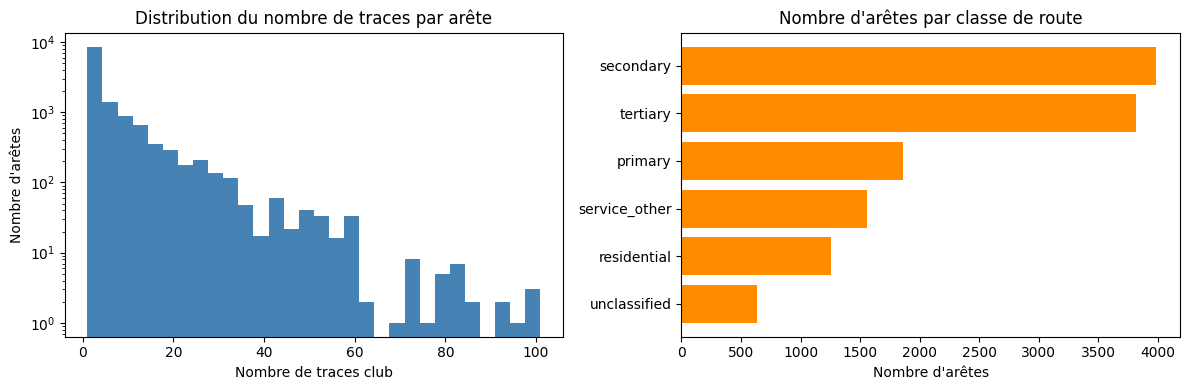

In [38]:
# Distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(heatmap["n_traces_club"], bins=30, color="steelblue")
axes[0].set_title("Distribution du nombre de traces par arête")
axes[0].set_xlabel("Nombre de traces club")
axes[0].set_ylabel("Nombre d'arêtes")
axes[0].set_yscale("log")

# Par classe de route
if heatmap["highway"].notna().any():
    by_class = heatmap.groupby("highway")["n_traces_club"].agg(["count", "mean"])
    by_class = by_class.sort_values("count", ascending=True)
    axes[1].barh(by_class.index, by_class["count"], color="darkorange")
    axes[1].set_title("Nombre d'arêtes par classe de route")
    axes[1].set_xlabel("Nombre d'arêtes")

plt.tight_layout()
plt.show()

## 9. Découpage des boucles en sous-tronçons

### Pourquoi

Une boucle club de 120 km n'est pas directement utilisable pour un routing
A→B. Mais elle contient des **tronçons de 5-15 km** (par exemple "le passage
entre Chevreuse et Dampierre via la D91") qui sont réutilisables tels quels.

### Stratégie

Pour cette première version, découpage **uniforme par distance** : chaque
boucle est découpée tous les ~10 km en tronçons consécutifs. On garde les
arêtes dans l'ordre.

**Plus tard (Notebook 4)**, on passera à un découpage plus intelligent aux
**intersections majeures** (nœuds OSM de degré ≥ 4 sur routes principales),
ce qui donnera des tronçons sémantiquement cohérents.

In [39]:
# Paramètre du découpage
SEGMENT_TARGET_KM = 10.0

# Table des sous-tronçons : on la crée si absente
with engine.begin() as conn:
    conn.execute(text("""
        CREATE TABLE IF NOT EXISTS trace_segments (
            segment_id      SERIAL PRIMARY KEY,
            trace_id        INTEGER NOT NULL,
            seg_seq         INTEGER NOT NULL,
            edge_id_start   BIGINT,
            edge_id_end     BIGINT,
            n_edges         INTEGER,
            length_m        DOUBLE PRECISION,
            FOREIGN KEY (trace_id) REFERENCES traces(trace_id) ON DELETE CASCADE
        );
        CREATE TABLE IF NOT EXISTS trace_segment_edges (
            segment_id  INTEGER NOT NULL,
            edge_id     BIGINT NOT NULL,
            seq         INTEGER NOT NULL,
            PRIMARY KEY (segment_id, seq),
            FOREIGN KEY (segment_id) REFERENCES trace_segments(segment_id) ON DELETE CASCADE
        );
        TRUNCATE TABLE trace_segment_edges, trace_segments RESTART IDENTITY CASCADE;
    """))
print("Tables trace_segments et trace_segment_edges créées / vidées.")

Tables trace_segments et trace_segment_edges créées / vidées.


In [40]:
# --- Découpage uniforme ---
# Pour chaque trace, on parcourt ses arêtes dans l'ordre (seq), on cumule la
# longueur, et on coupe dès qu'on atteint SEGMENT_TARGET_KM.

insert_seg_sql = text("""
INSERT INTO trace_segments (trace_id, seg_seq, edge_id_start, edge_id_end, n_edges, length_m)
VALUES (:trace_id, :seg_seq, :edge_id_start, :edge_id_end, :n_edges, :length_m)
RETURNING segment_id;
""")

insert_seg_edge_sql = text("""
INSERT INTO trace_segment_edges (segment_id, edge_id, seq)
VALUES (:segment_id, :edge_id, :seq);
""")

# Requête qui nous donne les arêtes en ordre pour chaque trace
with engine.connect() as conn:
    ordered = pd.read_sql(text("""
        SELECT te.trace_id, te.seq, te.edge_id, e.length_m
        FROM trace_edges te
        JOIN osm_edges e ON e.edge_id = te.edge_id
        ORDER BY te.trace_id, te.seq;
    """), conn)

print(f"{len(ordered)} (trace_id, edge_id) à découper")

segments_built = 0
with engine.begin() as conn:
    for trace_id, grp in tqdm(ordered.groupby("trace_id"), desc="Découpage"):
        seg_seq = 0
        current_edges = []   # liste de (edge_id, length_m)
        current_len = 0.0

        for _, row in grp.iterrows():
            edge_id = int(row["edge_id"])
            length  = float(row["length_m"] or 0)
            current_edges.append((edge_id, length))
            current_len += length

            if current_len >= SEGMENT_TARGET_KM * 1000:
                # On ferme ce segment
                segment_id = conn.execute(insert_seg_sql, {
                    "trace_id":       int(trace_id),
                    "seg_seq":        seg_seq,
                    "edge_id_start":  current_edges[0][0],
                    "edge_id_end":    current_edges[-1][0],
                    "n_edges":        len(current_edges),
                    "length_m":       current_len,
                }).scalar()
                # Ses arêtes
                seg_edge_params = [
                    {"segment_id": segment_id, "edge_id": eid, "seq": i}
                    for i, (eid, _) in enumerate(current_edges)
                ]
                conn.execute(insert_seg_edge_sql, seg_edge_params)

                seg_seq += 1
                segments_built += 1
                current_edges = []
                current_len = 0.0

        # Reliquat : on l'enregistre s'il fait au moins 2 km
        if current_edges and current_len >= 2000:
            segment_id = conn.execute(insert_seg_sql, {
                "trace_id":       int(trace_id),
                "seg_seq":        seg_seq,
                "edge_id_start":  current_edges[0][0],
                "edge_id_end":    current_edges[-1][0],
                "n_edges":        len(current_edges),
                "length_m":       current_len,
            }).scalar()
            seg_edge_params = [
                {"segment_id": segment_id, "edge_id": eid, "seq": i}
                for i, (eid, _) in enumerate(current_edges)
            ]
            conn.execute(insert_seg_edge_sql, seg_edge_params)
            segments_built += 1

print(f"\n✓ {segments_built} sous-tronçons construits")

205907 (trace_id, edge_id) à découper


Découpage: 100%|██████████| 147/147 [00:46<00:00,  3.14it/s]


✓ 1655 sous-tronçons construits


In [41]:
# Stats rapides sur les sous-tronçons
with engine.connect() as conn:
    seg_stats = pd.read_sql(text("""
        SELECT
            COUNT(*) AS n_segments,
            AVG(length_m)/1000 AS avg_km,
            MIN(length_m)/1000 AS min_km,
            MAX(length_m)/1000 AS max_km,
            AVG(n_edges) AS avg_edges
        FROM trace_segments;
    """), conn)
print(seg_stats.to_string(index=False))

 n_segments  avg_km  min_km  max_km  avg_edges
       1655 9.85064   2.108  11.334  124.06284


## 10. Rapport final

In [42]:
print("=" * 60)
print("RAPPORT NOTEBOOK 2")
print("=" * 60)

with engine.connect() as conn:
    n_traces_matched = sum(1 for r in results.values() if not r["error"])
    n_osm_edges      = conn.execute(text("SELECT COUNT(*) FROM osm_edges")).scalar()
    n_trace_edges    = conn.execute(text("SELECT COUNT(*) FROM trace_edges")).scalar()
    n_segments       = conn.execute(text("SELECT COUNT(*) FROM trace_segments")).scalar()
    total_edge_km    = conn.execute(text("""
        SELECT SUM(length_m)/1000 FROM osm_edges;
    """)).scalar()

print(f"Traces matchées          : {n_traces_matched} / {len(traces_df)}")
print(f"Erreurs matching         : {len(errors)}")
print()
print(f"Arêtes OSM uniques       : {n_osm_edges:,}")
print(f"Passages totaux          : {n_trace_edges:,}")
print(f"Distance couverte (km)   : {total_edge_km:,.0f}")
print()
print(f"Sous-tronçons construits : {n_segments}")
print("=" * 60)

RAPPORT NOTEBOOK 2
Traces matchées          : 147 / 148
Erreurs matching         : 1

Arêtes OSM uniques       : 13,120
Passages totaux          : 205,907
Distance couverte (km)   : 1,048

Sous-tronçons construits : 1655


## Ce qu'on a accompli

✓ Valhalla déployé en Docker local avec extrait IdF
✓ Map-matching de toutes les traces club (arêtes OSM identifiées)
✓ Stockage propre : `osm_edges` + `trace_edges` + `trace_segments`
✓ Heatmap club par arête (= score club-worthy base)
✓ Découpage en sous-tronçons de ~10 km réutilisables

## Ce qu'on **n'a pas encore** : à faire au Notebook 3

- Les **géométries** des arêtes (`osm_edges.geom` est encore NULL) — il faudra
  extraire les `LINESTRING` depuis OSM via `osmnx` ou `pyrosm`
- Tous les **tags OSM riches** (lcn/rcn, cycleway:left/right, etc.)
- Les **arêtes hors traces club** (la grande majorité de l'IdF). Pour l'instant
  `osm_edges` ne contient QUE les arêtes empruntées par le club.

Le Notebook 3 téléchargera OSM IdF complet et fusionnera avec ce qu'on a.

## Prochaine étape : Notebook 3

1. Download OSM IdF complet via `pyrosm` ou `osmnx`
2. Remplir `osm_edges.geom` pour **toutes** les arêtes d'IdF
3. Ajout des tags OSM riches
4. Intégration Strava Segments via OAuth officiel
5. Import data.gouv pistes cyclables IdF
6. Calcul du `score_osm` composite
